# 10. 일반 선형 모델 및 최소제곱법

## 모든 점을 지나지 못할 때 가장 가까운 선 찾기

- **배울 것**: 설계행렬, 절편, 잔차, 정규방정식, QR 해법.
- 관측값 $y$를 여러 설명변수의 선형결합으로 근사합니다. 여기서 일반 선형 모델은 계수에 대해 선형인 모델을 말합니다.

$$
y=X\beta+\varepsilon,\qquad
\hat\beta=\arg\min_\beta\|y-X\beta\|_2^2
$$

- 직선 $y\approx\beta_0+\beta_1x$의 설계행렬은 `np.column_stack([np.ones(N), x])`입니다.
- 1로 된 열을 생략하면 절편이 0으로 고정됩니다. 이때 적합선은 반드시 원점을 지나야 합니다.
- 예시 $x=(1,2,3,4,5)$, $y=(0,3,2,5,5)$의 최소제곱 직선은 $\hat y=-0.6+1.2x$입니다. 예측은 $(0.6,1.8,3,4.2,5.4)$, SSE는 3.6입니다.

## 최소제곱은 직교 투영이다

$$
X^T(y-X\hat\beta)=0,\qquad
\hat\beta=(X^TX)^{-1}X^Ty
$$

- 두 번째 식은 X가 완전열랭크일 때의 공식입니다. 첫 식은 잔차가 설계행렬의 모든 열에 수직이라는 뜻입니다.
- 예측값은 $\mathcal C(X)$ 안에 있고 잔차는 $\mathcal N(X^T)$ 안에 있습니다.
- 절편이 포함되면 잔차의 합도 0입니다. 관측 벡터를 ‘설명한 부분’과 ‘설명하지 못한 부분’으로 직교 분해한 셈입니다.

$$
X=QR\Rightarrow R\hat\beta=Q^Ty
$$

- 원본은 역행렬 공식과 QR을 비교합니다. 일반적인 구현에는 `np.linalg.lstsq(X,y,rcond=None)`가 간편합니다.
- 큰 잔차를 제곱하므로 이상치 하나가 계수를 크게 바꿀 수 있습니다. 이상치의 x위치에 따라서도 영향이 다릅니다.
- **주의**: 적합은 인과를 증명하지 않습니다. 원본의 수강 과목 수·행복도 예제는 계산을 이해하기 위한 학습용 데이터입니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch10'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260935)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260935)

재현용 난수 시드: 20260935


### 코드 10-01

- 원본: `original_py/LA4DS_ch10.py` 1–13행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# null space
from scipy.linalg import null_space

import sympy as sym


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 코드 10-02

- 원본: `original_py/LA4DS_ch10.py` 19–40행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

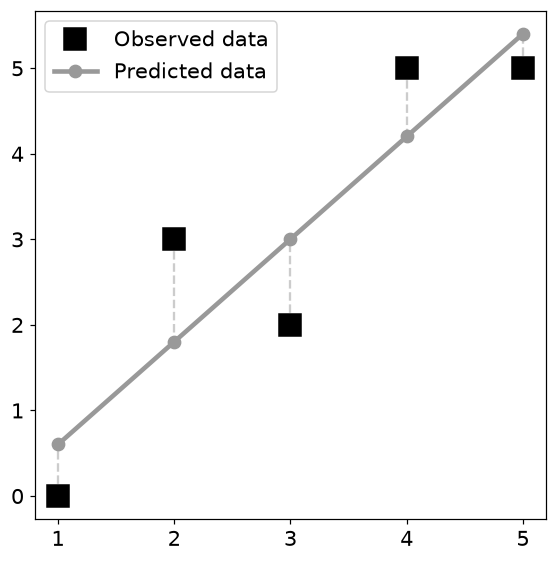

In [3]:
## this code creates figure 2

# data
x = [ 1,2,3,4,5 ]
y = [ 0,3,2,5,5 ]

# model
X = np.hstack((np.ones((5,1)),np.array(x,ndmin=2).T))
yHat = X @ np.linalg.inv(X.T@X) @ X.T @ y

# plot the data and predicted values
plt.figure(figsize=(6,6))
plt.plot(x,y,'ks',markersize=15,label='Observed data')
plt.plot(x,yHat,'o-',color=[.6,.6,.6],linewidth=3,markersize=8,label='Predicted data')

# plot the residuals (errors)
for n,y,yHat in zip(x,y,yHat):
  plt.plot([n,n],[y,yHat],'--',color=[.8,.8,.8],zorder=-10)

plt.legend()
plt.savefig(ASSET / 'Figure_10_02.png',dpi=140)
plt.show()

### 학습용 데이터로 회귀하기

### 코드 10-03

- 원본: `original_py/LA4DS_ch10.py` 44–57행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

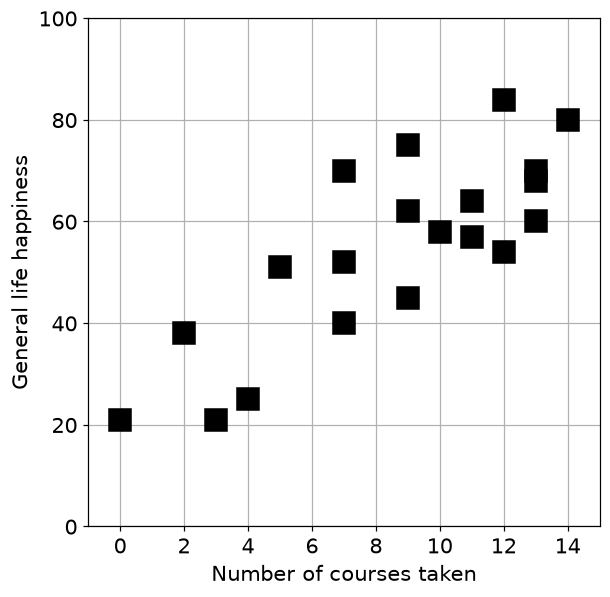

In [4]:
numcourses = [13,4,12,3,14,13,12,9,11,7,13,11,9,2,5,7,10,0,9,7]
happiness  = [70,25,54,21,80,68,84,62,57,40,60,64,45,38,51,52,58,21,75,70]

plt.figure(figsize=(6,6))

plt.plot(numcourses,happiness,'ks',markersize=15)
plt.xlabel('Number of courses taken')
plt.ylabel('General life happiness')
plt.xlim([-1,15])
plt.ylim([0,100])
plt.grid()
plt.xticks(range(0,15,2))
plt.savefig(ASSET / 'Figure_10_03.png',dpi=140)
plt.show()

### 코드 10-04

- 원본: `original_py/LA4DS_ch10.py` 59–70행.

In [5]:
# Build a statistical model

# design matrix as a column vector
X = np.array(numcourses,ndmin=2).T
print(X.shape)

# fit the model using the left-inverse
X_leftinv = np.linalg.inv(X.T@X) @ X.T

# solve for the coefficients
beta = X_leftinv @ happiness
beta

(20, 1)
Out[5]: array([5.924029])


### 코드 10-05

- 원본: `original_py/LA4DS_ch10.py` 72–96행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

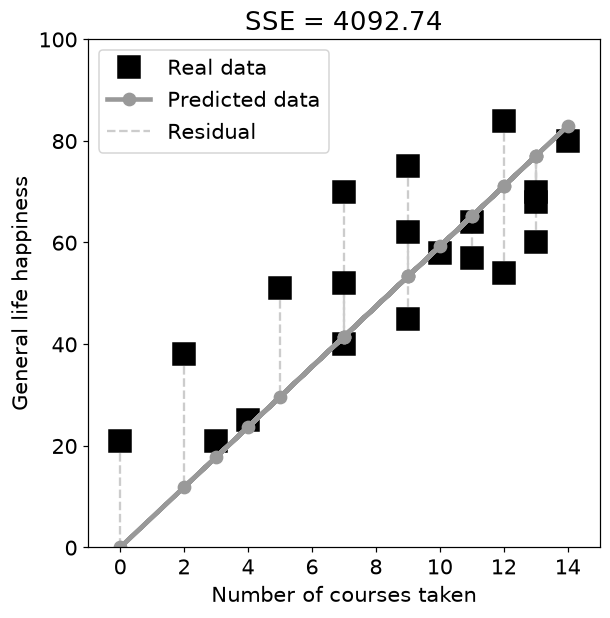

In [6]:
# let's plot it!

# predicted data
pred_happiness = X@beta


plt.figure(figsize=(6,6))

# plot the data and predicted values
plt.plot(numcourses,happiness,'ks',markersize=15)
plt.plot(numcourses,pred_happiness,'o-',color=[.6,.6,.6],linewidth=3,markersize=8)

# plot the residuals (errors)
for n,y,yHat in zip(numcourses,happiness,pred_happiness):
  plt.plot([n,n],[y,yHat],'--',color=[.8,.8,.8],zorder=-10)

plt.xlabel('Number of courses taken')
plt.ylabel('General life happiness')
plt.xlim([-1,15])
plt.ylim([0,100])
plt.xticks(range(0,15,2))
plt.legend(['Real data','Predicted data','Residual'])
plt.title(f'SSE = {np.sum((pred_happiness-happiness)**2):.2f}')
plt.savefig(ASSET / 'Figure_10_04.png',dpi=140)
plt.show()

### 코드 10-06

- 원본: `original_py/LA4DS_ch10.py` 98–109행.

In [7]:
# Build a statistical model with an intercept

# design matrix as a column vector
X = np.hstack((np.ones((20,1)),np.array(numcourses,ndmin=2).T))
print(X.shape)

# fit the model using the left-inverse
X_leftinv = np.linalg.inv(X.T@X) @ X.T

# solve for the coefficients
beta = X_leftinv @ happiness
beta

(20, 2)
Out[7]: array([23.130338,  3.698206])


### 코드 10-07

- 원본: `original_py/LA4DS_ch10.py` 111–135행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

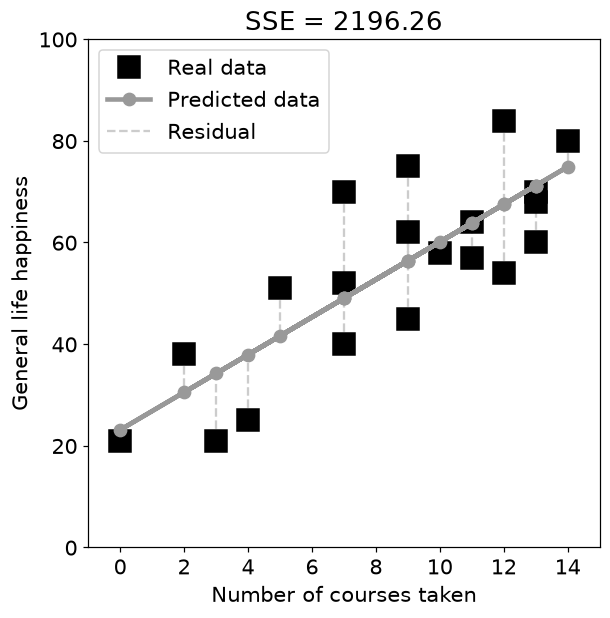

In [8]:
# let's plot it!

# predicted data
pred_happiness = X@beta


plt.figure(figsize=(6,6))

# plot the data and predicted values
plt.plot(numcourses,happiness,'ks',markersize=15)
plt.plot(numcourses,pred_happiness,'o-',color=[.6,.6,.6],linewidth=3,markersize=8)

# plot the residuals (errors)
for n,y,yHat in zip(numcourses,happiness,pred_happiness):
  plt.plot([n,n],[y,yHat],'--',color=[.8,.8,.8],zorder=-10)

plt.xlabel('Number of courses taken')
plt.ylabel('General life happiness')
plt.xlim([-1,15])
plt.ylim([0,100])
plt.xticks(range(0,15,2))
plt.legend(['Real data','Predicted data','Residual'])
plt.title(f'SSE = {np.sum((pred_happiness-happiness)**2):.2f}')
plt.savefig(ASSET / 'Figure_10_05.png',dpi=140)
plt.show()

## 연습문제 1 · 예측과 잔차의 직교

- **목표**: 최소제곱 잔차가 예측벡터에 수직임을 확인합니다.
- **풀이 순서**: 절편 포함 모델의 잔차를 구하고 예측과의 내적·상관을 출력해 산점도로 봅니다.
- **결과 해석**: 둘 다 0 근처입니다. 상관은 중심화·노름 정규화를 포함하므로 내적과 단위가 다릅니다. 수치 크기를 곧바로 정확도 우열로 읽지 않습니다.

### 코드 10-08

- 원본: `original_py/LA4DS_ch10.py` 139–156행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

Dot product: -5.752553988713771e-11
Correlation: -1.9724313754422123e-16
 


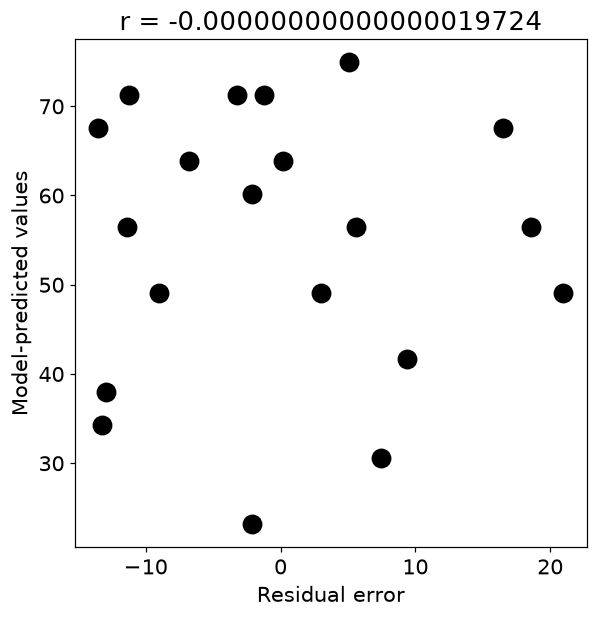

In [9]:
# compute residual
res = happiness-pred_happiness


# should be zero + some error
print('Dot product: ' + str(np.dot(pred_happiness,res)) )
print('Correlation: ' + str(np.corrcoef(pred_happiness,res)[0,1]))
print(' ')


# show in a plot
plt.figure(figsize=(6,6))
plt.plot(res,pred_happiness,'ko',markersize=12)
plt.xlabel('Residual error')
plt.ylabel('Model-predicted values')
plt.title(f'r = {np.corrcoef(pred_happiness,res)[0,1]:.20f}')
plt.savefig(ASSET / 'Figure_10_06.png',dpi=140)
plt.show()

### 코드 10-09

- 원본: `original_py/LA4DS_ch10.py` 158–159행.

In [10]:
# correlation is smaller because we're dividing by the vector norms, e.g.,
np.linalg.norm(res)

Out[10]: np.float64(46.86431997187644)


## 연습문제 2 · 잔차의 왼쪽 영공간 소속

- **목표**: 잔차가 X의 모든 열에 수직임을 확인합니다.
- **풀이 순서**: `null_space(X.T)`의 기저에 잔차를 열로 붙여 랭크가 증가하는지 검사합니다.
- **결과 해석**: 두 랭크가 같으면 잔차는 이미 그 공간 안에 있습니다. 원본 출력의 N(X)는 실제로 계산한 N(X.T)로 읽어야 합니다.

### 코드 10-10

- 원본: `original_py/LA4DS_ch10.py` 163–180행.

In [11]:
# the residual is orthogonal to the entire column space of the design matrix.

# I demonstrated this by showing that the residuals vector is in the left-null space of the design matrix.
# I did that by using scipy.linalg.null_space to find the left-null space, augmenting that null-space basis
# matrix by the residuals vector, and showing that the null space and augmented null space have the same rank.


# compute the null space (via scipy.linalg)
nullspace = null_space(X.T)


# augment the residuals
nullspaceAugment = np.hstack( (nullspace,res.reshape(-1,1)) )


# print their ranks
print(f'dim(  N(X)    ) = {np.linalg.matrix_rank(nullspace)}')
print(f'dim( [N(X)|r] ) = {np.linalg.matrix_rank(nullspaceAugment)}')

dim(  N(X)    ) = 18
dim( [N(X)|r] ) = 18


## 연습문제 3 · 세 가지 최소제곱 계산

- **목표**: 정규방정식, QR 역행렬, QR 확대행렬 풀이를 비교합니다.
- **풀이 순서**: 동일한 X와 y로 계수를 각각 계산하고 소수 셋째 자리까지 출력합니다.
- **결과 해석**: 계수들이 일치합니다. 실수 확대행렬의 RREF는 학습용이며 큰 수치 문제에는 전용 QR/SVD 솔버가 적합합니다.

### 코드 10-11

- 원본: `original_py/LA4DS_ch10.py` 184–217행.

In [12]:
### Uncomment these lines to use random data
# random design matrix and data vector
# M,N = 20,3
# X = np.random.randn(M,N)
# happiness = np.random.randn(M,1)


# recreate the design matrix and solution via left-inverse
X = np.hstack((np.ones((20,1)),np.array(numcourses,ndmin=2).T))
beta1 = np.linalg.inv(X.T@X) @ X.T @ happiness


# QR decomp
Q,R = np.linalg.qr(X)

# beta coefficients implemented as translation of the math
beta2 = np.linalg.inv(R) @ (Q.T@happiness)

# and using back-substitution via RREF
# Q'y, but needs to be reshaped into a column vector
tmp = (Q.T@happiness).reshape(-1,1)
Raug = np.hstack( (R,tmp) ) # augment the matrix
Raug_r = sym.Matrix(Raug).rref()[0] # this gets the matrix
beta3 = np.array(Raug_r[:,-1]) # convert back to numpy


print('Betas from left-inverse: ')
print(np.round(beta1,3)), print(' ')

print('Betas from QR with inv(R): ')
print(np.round(beta2,3)), print(' ')

print('Betas from QR with back-substitution: ')
print(np.round(np.array(beta3.T).astype(float),3)) # transposed to facilitate visual inspection

Betas from left-inverse: 
[23.13   3.698]
 
Betas from QR with inv(R): 
[23.13   3.698]
 
Betas from QR with back-substitution: 
[[23.13   3.698]]


### 코드 10-12

- 원본: `original_py/LA4DS_ch10.py` 219–229행.

In [13]:
# show the matrices
print('Matrix R:')
print(np.round(R,3)) # note that it's upper-triangular (as you know!)

print(' ')
print("Matrix R|Q'y:")
print(np.round(Raug,3))

print(' ')
print("Matrix RREF(R|Q'y):")
print(np.round(np.array(Raug_r).astype(float),3)) # convert to numpy floats

Matrix R:
[[ -4.472 -38.237]
 [  0.     17.747]]
 
Matrix R|Q'y:
[[  -4.472  -38.237 -244.849]
 [   0.      17.747   65.631]]
 
Matrix RREF(R|Q'y):
[[ 1.     0.    23.13 ]
 [ 0.     1.     3.698]]


## 연습문제 4 · 이상치의 영향

- **목표**: 같은 큰 오차라도 x위치에 따라 회귀선이 다르게 변함을 봅니다.
- **풀이 순서**: 정상 데이터와 서로 다른 위치의 y를 170으로 바꾼 두 데이터를 같은 X로 적합합니다. 각 SSE를 계산합니다.
- **결과 해석**: 절편과 기울기가 다르게 변합니다. 원본 루프의 y 덮어쓰기 때문에 SSE 제목이 잘못 계산될 수 있어 변수명을 분리하고 축 범위도 확대했습니다.

### 코드 10-13

- 원본: `original_py/LA4DS_ch10.py` 233–273행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 잔차 표시 루프가 전체 y 벡터를 덮어쓰지 않게 수정했습니다.
- **보완**: 관측값 변수명을 분리했습니다.
- **보완**: 170인 이상치도 그림에 보이도록 y축 범위를 확대했습니다.

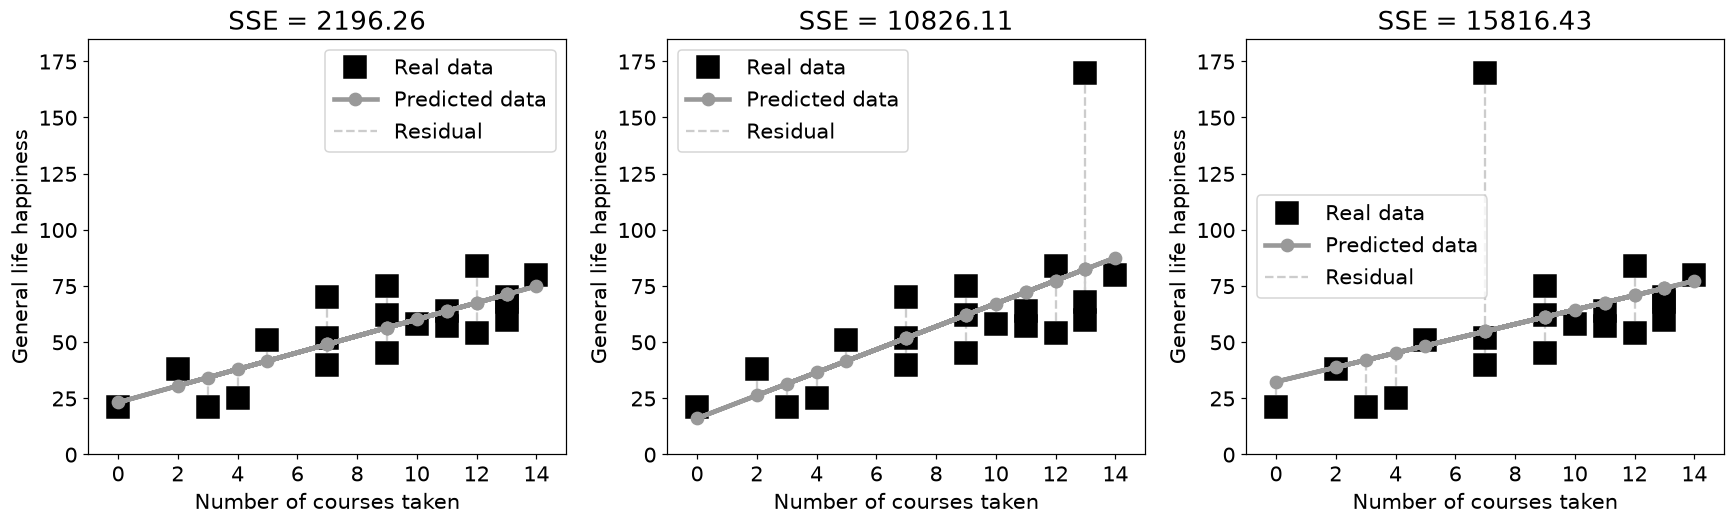

In [14]:
# happiness with outliers due to typos (oops!)
happiness_oops1 = [170,25,54,21,80,68,84,62,57,40,60,64,45,38,51,52,58,21,75,70]
happiness_oops2 = [70,25,54,21,80,68,84,62,57,40,60,64,45,38,51,52,58,21,75,170]


# design matrix and its left-inverse (doesn't change with the data)
X = np.hstack((np.ones((20,1)),np.array(numcourses,ndmin=2).T))
X_leftinv = np.linalg.inv(X.T@X) @ X.T



_,axs = plt.subplots(1,3,figsize=(16,5))

for axi,y in zip(axs,[happiness,happiness_oops1,happiness_oops2]):

  # compute the best-fit parameters
  beta = X_leftinv @ y

  # predicted data
  pred_happiness = X@beta


  # plot the data and predicted values
  axi.plot(numcourses,y,'ks',markersize=15)
  axi.plot(numcourses,pred_happiness,'o-',color=[.6,.6,.6],linewidth=3,markersize=8)

  # plot the residuals (errors)
  for n,y_obs,yHat in zip(numcourses,y,pred_happiness):
    axi.plot([n,n],[y_obs,yHat],'--',color=[.8,.8,.8],zorder=-10)

  # make the plot look nicer
  axi.set(xlabel='Number of courses taken',ylabel='General life happiness',
          xlim=[-1,15],ylim=[0,185],xticks=range(0,15,2))
  axi.legend(['Real data','Predicted data','Residual'])
  axi.set_title(f'SSE = {np.sum((pred_happiness-y)**2):.2f}')
  


plt.tight_layout()
plt.savefig(ASSET / 'Figure_10_07.png',dpi=140)
plt.show()

## 연습문제 5 · 최소제곱으로 역행렬 찾기

- **목표**: $XX^{-1}=I$를 여러 우변에 대한 선형계로 봅니다.
- **풀이 순서**: 항등행렬 각 열을 목표 y로 두고 해를 모읍니다. 행렬 전체를 한 번에 푼 결과와 inv(X)를 비교합니다.
- **결과 해석**: 완전랭크 정사각형이면 같은 역행렬입니다. 정규방정식은 조건수를 악화시킬 수 있어 오차 크기가 다르게 나타납니다.

### 코드 10-14

- 원본: `original_py/LA4DS_ch10.py` 277–324행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

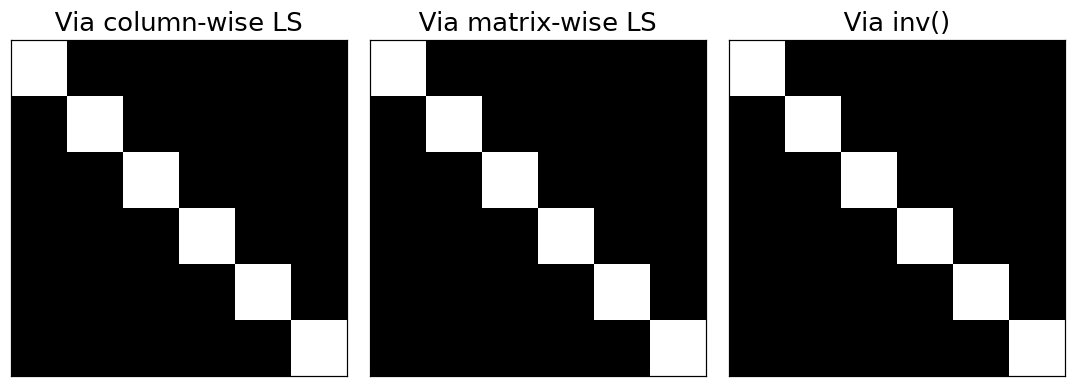

In [15]:
# matrix size
n = 6

# some random "design matrix"
X = np.random.randn(n,n)

# the target matrix (identity)
Y = np.eye(n)


# find the best-fitting model one column at a time
Xinv1 = np.zeros_like(X)

for coli in range(n):
  Xinv1[:,coli] = np.linalg.inv(X.T@X) @ X.T @ Y[:,coli]



# repeat but without a loop
Xinv2 = np.linalg.inv(X.T@X) @ X.T @ Y


# and the inverse using inv()
Xinv3 = np.linalg.inv(X)


# visualize
_,axs = plt.subplots(1,3,figsize=(10,6))

# column-wise least-squares
axs[0].imshow( Xinv1@X ,cmap='gray')
axs[0].set_title('Via column-wise LS')

# matrix-wise least-squares
axs[1].imshow( Xinv2@X ,cmap='gray' )
axs[1].set_title('Via matrix-wise LS')

# inv()
axs[2].imshow( Xinv3@X ,cmap='gray' )
axs[2].set_title('Via inv()')


# don't need the tick marks
for a in axs: a.set(xticks=[],yticks=[])

plt.tight_layout()
plt.savefig(ASSET / 'Figure_10_08.png',dpi=140)
plt.show()

### 코드 10-15

- 원본: `original_py/LA4DS_ch10.py` 326–337행.

In [16]:
# show they are equivalent 
# Note the relatively large rounding errors when comparing to inv() -- the left-inverse
#   least-squares method is not a numerically stable method!


print(Xinv1-Xinv2)
print(' ')

print(Xinv1-Xinv3)
print(' ')

print(Xinv2-Xinv3)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
 
[[-0. -0. -0. -0.  0.  0.]
 [-0. -0.  0. -0.  0. -0.]
 [ 0. -0.  0. -0.  0.  0.]
 [ 0. -0.  0.  0. -0. -0.]
 [ 0. -0.  0. -0.  0.  0.]
 [-0. -0.  0. -0.  0.  0.]]
 
[[-0. -0. -0. -0.  0.  0.]
 [-0. -0.  0. -0.  0. -0.]
 [ 0. -0.  0. -0.  0.  0.]
 [ 0. -0.  0.  0. -0. -0.]
 [ 0. -0.  0. -0.  0.  0.]
 [-0. -0.  0. -0.  0.  0.]]


## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [17]:
_x=np.arange(1.,6.); _y=np.array([0.,3.,2.,5.,5.])
_X=np.column_stack([np.ones(5),_x]); _b=np.linalg.lstsq(_X,_y,rcond=None)[0]
_e=_y-_X@_b
print('절편, 기울기:',_b,'SSE:',round(_e@_e,6))
print('X.T @ 잔차:',_X.T@_e)
assert np.allclose(_b,[-.6,1.2]) and np.allclose(_e@_e,3.6)
assert np.allclose(_X.T@_e,0)


절편, 기울기: [-0.6  1.2] SSE: 3.6
X.T @ 잔차: [-0.  0.]
